In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
train_dir = "../smartvision_dataset/classification/train"
val_dir = "../smartvision_dataset/classification/val"
test_dir = "../smartvision_dataset/classification/test"

In [4]:
img_size = (224,224)
batch_size = 16

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical"
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical"
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

Found 1749 images belonging to 25 classes.
Found 375 images belonging to 25 classes.
Found 375 images belonging to 25 classes.


In [5]:
num_classes = train_data.num_classes

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)
for layer in base_model.layers:
    layer.trainable = False


x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(64, activation="relu",
                 kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
x
x = layers.Dropout(0.5)(x)

output = layers.Dense(num_classes, activation="softmax")(x)
model = models.Model(inputs=base_model.input, outputs=output)

In [6]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=3),
    ModelCheckpoint("../models/resnet50_best.h5", monitor="val_loss", save_best_only=True)
]

In [7]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
result = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0614 - loss: 5.2797

110/110 ━━━━━━━━━━━━━━━━━━━━ 168s 1s/step - accuracy: 0.0755 - loss: 5.0679 - val_accuracy: 0.1733 - val_loss: 4.1043 - learning_rate: 1.0000e-04
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1298 - loss: 4.4738

110/110 ━━━━━━━━━━━━━━━━━━━━ 150s 1s/step - accuracy: 0.1475 - loss: 4.3903 - val_accuracy: 0.3040 - val_loss: 3.6955 - learning_rate: 1.0000e-04
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1771 - loss: 4.1344

110/110 ━━━━━━━━━━━━━━━━━━━━ 154s 1s/step - accuracy: 0.2075 - loss: 4.0073 - val_accuracy: 0.3707 - val_loss: 3.4161 - learning_rate: 1.0000e-04
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2788 - loss: 3.7246

110/110 ━━━━━━━━━━━━━━━━━━━━ 155s 1s/step - accuracy: 0.2887 - loss: 3.6938 - val_accuracy: 0.4267 - val_loss: 3.2142 - learning_rate: 1.0000e-04
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3302 - loss: 3.5540

...

110/110 ━━━━━━━━━━━━━━━━━━━━ 149s 1s/step - accuracy: 0.5575 - loss: 2.5635 - val_accuracy: 0.6480 - val_loss: 2.3441 - learning_rate: 1.0000e-04
Epoch 17/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5641 - loss: 2.5378

110/110 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.5586 - loss: 2.5186 - val_accuracy: 0.6533 - val_loss: 2.3169 - learning_rate: 1.0000e-04
Epoch 18/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5855 - loss: 2.4495

110/110 ━━━━━━━━━━━━━━━━━━━━ 152s 1s/step - accuracy: 0.5780 - loss: 2.4593 - val_accuracy: 0.6747 - val_loss: 2.2841 - learning_rate: 1.0000e-04
Epoch 19/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5947 - loss: 2.4176

110/110 ━━━━━━━━━━━━━━━━━━━━ 147s 1s/step - accuracy: 0.5895 - loss: 2.4219 - val_accuracy: 0.6720 - val_loss: 2.2558 - learning_rate: 1.0000e-04
Epoch 20/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5714 - loss: 2.4465

110/110 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.5746 - loss: 2.4144 - val_accuracy: 0.6827 - val_loss: 2.2317 - learning_rate: 1.0000e-04


In [9]:
for layer in base_model.layers[-10:]:
    layer.trainable = True

for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00003),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5851 - loss: 2.3862

110/110 ━━━━━━━━━━━━━━━━━━━━ 184s 2s/step - accuracy: 0.5901 - loss: 2.3853 - val_accuracy: 0.6907 - val_loss: 2.2071 - learning_rate: 3.0000e-05
Epoch 2/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6437 - loss: 2.1918

110/110 ━━━━━━━━━━━━━━━━━━━━ 182s 2s/step - accuracy: 0.6198 - loss: 2.2521 - val_accuracy: 0.6907 - val_loss: 2.1809 - learning_rate: 3.0000e-05
Epoch 3/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6313 - loss: 2.2127

110/110 ━━━━━━━━━━━━━━━━━━━━ 175s 2s/step - accuracy: 0.6364 - loss: 2.2111 - val_accuracy: 0.6907 - val_loss: 2.1506 - learning_rate: 3.0000e-05
Epoch 4/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6706 - loss: 2.0780

110/110 ━━━━━━━━━━━━━━━━━━━━ 174s 2s/step - accuracy: 0.6621 - loss: 2.1176 - val_accuracy: 0.7227 - val_loss: 2.1104 - learning_rate: 3.0000e-05
Epoch 5/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6572 - loss: 2.0963

...

110/110 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.8502 - loss: 1.3578 - val_accuracy: 0.7733 - val_loss: 1.8235 - learning_rate: 3.0000e-05
Epoch 25/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.8616 - loss: 1.3047 - val_accuracy: 0.7653 - val_loss: 1.8251 - learning_rate: 3.0000e-05
Epoch 26/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8690 - loss: 1.3021

110/110 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.8679 - loss: 1.3149 - val_accuracy: 0.7760 - val_loss: 1.8103 - learning_rate: 3.0000e-05
Epoch 27/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8724 - loss: 1.2764

110/110 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.8685 - loss: 1.2755 - val_accuracy: 0.7787 - val_loss: 1.8068 - learning_rate: 3.0000e-05
Epoch 28/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8597 - loss: 1.3111

110/110 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.8702 - loss: 1.2734 - val_accuracy: 0.7760 - val_loss: 1.7929 - learning_rate: 3.0000e-05
Epoch 29/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8782 - loss: 1.2295

110/110 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.8668 - loss: 1.2603 - val_accuracy: 0.7707 - val_loss: 1.7620 - learning_rate: 3.0000e-05
Epoch 30/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.8856 - loss: 1.2091 - val_accuracy: 0.7867 - val_loss: 1.7808 - learning_rate: 3.0000e-05


- Train 86
- Test 81

In [11]:
def prediction():
    model = models.load_model("../models/VGG16_best.h5")

    img_path = "../smartvision_dataset/detection/images/image_000002.jpg"
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    predictions = model.predict(img_array)

    class_indices = train_data.class_indices
    class_names = list(class_indices.keys())

    predicted_class = class_names[np.argmax(predictions)]

    return predicted_class

In [12]:
pred = prediction()
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 581ms/step


'person'

In [13]:
model = models.load_model("../models/resnet50_best.h5")
y_pred = model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_data.classes
print(classification_report(y_true, y_pred_classes, target_names=list(test_data.class_indices.keys())))

24/24 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step 
               precision    recall  f1-score   support

     airplane       0.93      0.93      0.93        15
          bed       0.56      0.60      0.58        15
        bench       0.83      0.67      0.74        15
      bicycle       0.88      0.93      0.90        15
         bird       1.00      0.87      0.93        15
       bottle       0.92      0.80      0.86        15
         bowl       0.53      0.60      0.56        15
          bus       0.72      0.87      0.79        15
         cake       0.92      0.80      0.86        15
          car       0.82      0.93      0.88        15
          cat       0.70      0.93      0.80        15
        chair       0.94      1.00      0.97        15
        couch       0.55      0.40      0.46        15
          cow       0.82      0.93      0.88        15
          cup       0.83      0.67      0.74        15
          dog       0.92      0.73      0.81        15
     elephant       1.00

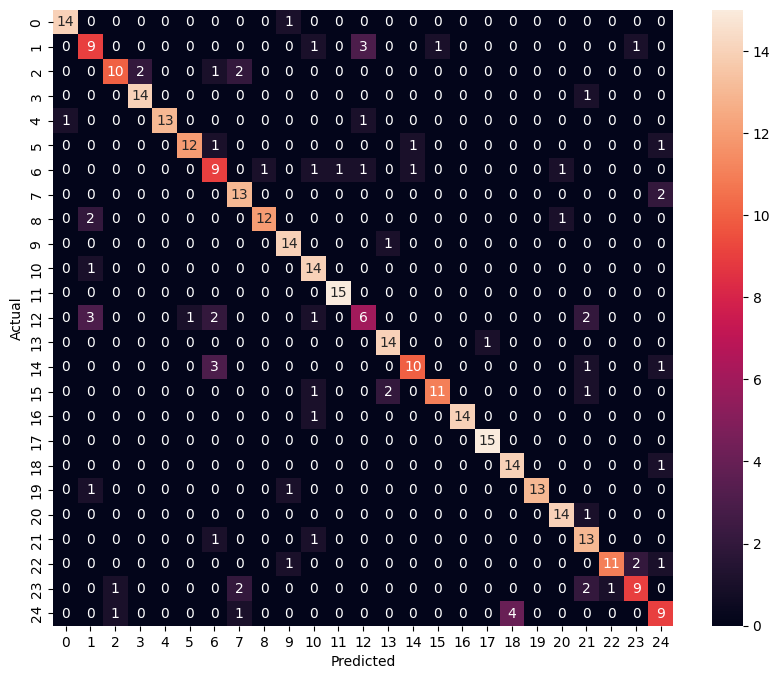

In [14]:
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()